In [1]:
import pandas as pd
import numpy as np
from os import listdir
from collections import OrderedDict

Average frequency of top-100 tags from vacancies for each keyword-query.

In [2]:
mypath = 'tags/'
mean_val = {}

for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'микросервис': 0.1489955076531433,
 'res_php': 0.13268970853908718,
 'EPAM': 0.12716078105789483,
 'res_Java': 0.1110812696742908,
 'res_Javascript': 0.10054028047185669,
 'Intern': 0.09896105786287984,
 'Spark': 0.08068730721429061,
 'res_Data scientist': 0.07777028130306775,
 'res_Python': 0.0770897474977555,
 'DevOps': 0.07660970647504703,
 'Typescript': 0.06782244520788494,
 'Golang': 0.0657664881877751,
 'php': 0.063007806182906,
 'Frontend': 0.05868688255498652,
 'Data': 0.0561887811823149,
 'Javascript': 0.05609971821628432,
 'C%23': 0.04806328856437805,
 'Java': 0.045561317841650635,
 'SQL': 0.04519379768312625,
 'Data scientist': 0.042371924955994525,
 'C%2B%2B': 0.040674007709976916,
 'Python': 0.03951051172297306}

Average frequency of top-5 tags from vacancies for each keyword-query.

In [3]:
for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].iloc[:5].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'res_php': 0.8023845459495609,
 'микросервис': 0.7170040446702982,
 'res_Java': 0.5916026858932735,
 'res_Javascript': 0.5801256101731803,
 'Spark': 0.5628087796557073,
 'EPAM': 0.55069815161382,
 'res_Python': 0.5083134564875282,
 'DevOps': 0.4836778130537112,
 'php': 0.4808371861292082,
 'Typescript': 0.4545087472941076,
 'Frontend': 0.4455009251151907,
 'Intern': 0.43296161309139125,
 'Golang': 0.4264002369640821,
 'Java': 0.3909942785397618,
 'res_Data scientist': 0.38644743968488426,
 'Javascript': 0.3644212853472719,
 'Python': 0.3629201624939758,
 'C%2B%2B': 0.34697830739754015,
 'Data': 0.3456259326732327,
 'C%23': 0.33356532542338996,
 'Data scientist': 0.27460442676818575,
 'SQL': 0.26778182540769685}

Average frequency of top-100 tags from vacancies for each keyword-query in last date.

In [4]:
mypath = 'tags/'
ordered_dict = OrderedDict()

for d in listdir(mypath):
    avg = []
    avg.append(pd.read_csv(mypath + d + '/' + listdir(mypath + d)[-1])['1.0'].mean())
    ordered_dict[d] = np.array(avg).mean()
    
ordered_dict = dict(sorted(ordered_dict.items(), key=lambda item: item[1], reverse=True))
# ordered_dict

Extracting date from names of files.

In [5]:
import re


date_x = ['9']
for name_file in listdir(mypath + '/Python'):
    date_x.append(re.findall('[0-9]{4}-[0-9]{2}-[0-9]{2}', name_file)[0])

Average frequency of top-100 tags from vacancies for each keyword-query and date, sorted by last date.

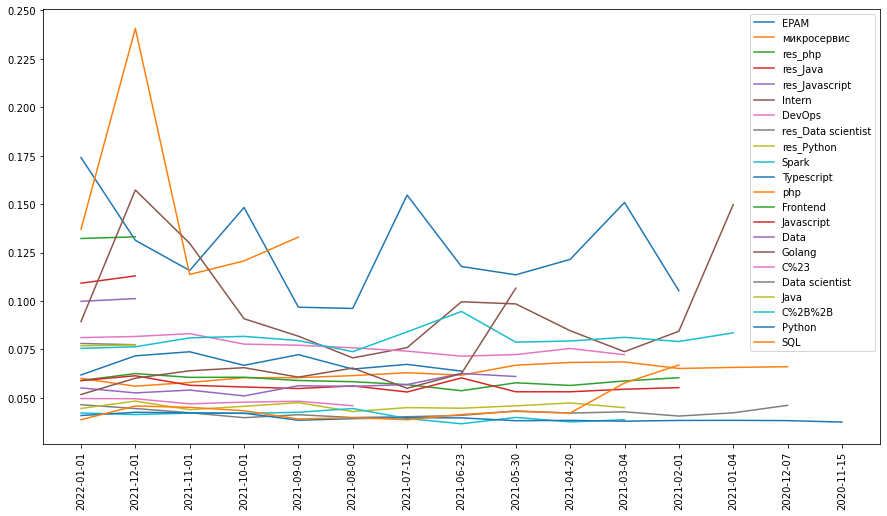

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


all_val = ordered_dict
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for d in listdir(mypath):
    val = []
    for f in listdir(mypath + d):
        val.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    all_val[d] = val[::-1]
    
all_val.keys()
[ax.plot(all_val[i]) for i in all_val.keys()]
ax.legend([i for i in all_val.keys()])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xticklabels(sorted(date_x, reverse=True), rotation=90)
plt.show()

In [7]:
# fig, ax = plt.subplots()
# fig.set_size_inches(15, 15)

# keywords = ordered_dict

# for i in listdir(mypath):
#     keywords[i] = pd.read_csv(mypath + i + '/' + listdir(mypath + i)[-1])['1.0']
#     ax.plot(keywords[i])

# ax.legend([i for i in keywords.keys()])